In [72]:
import pandas as pd
from glob import glob
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
datasets = ["mr", "vader_movie_2L", "aisopos", "subj"]
methods = ["biois", "drop3"]

/tmp/ipykernel_7788/3372070688.py:51: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


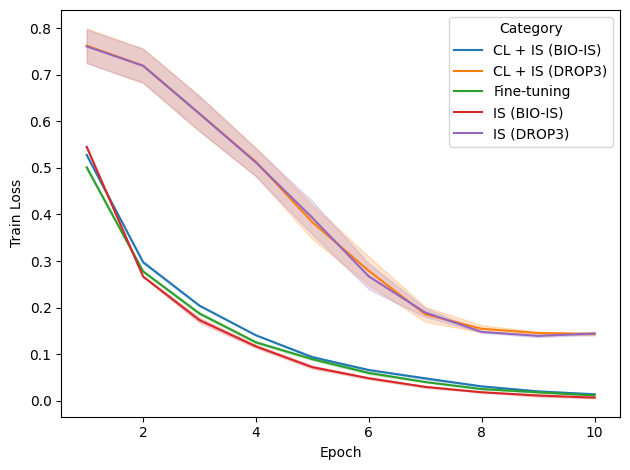

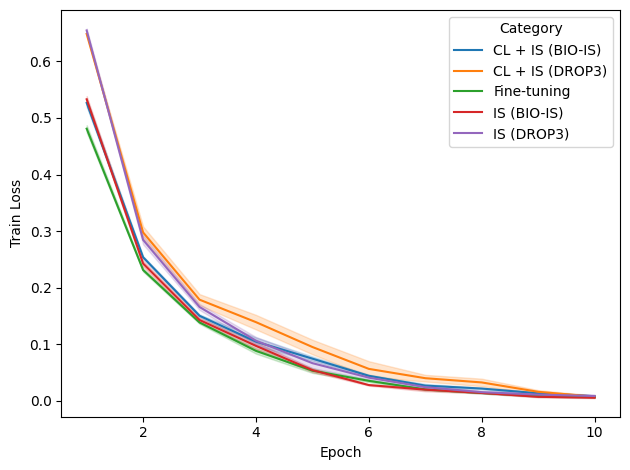

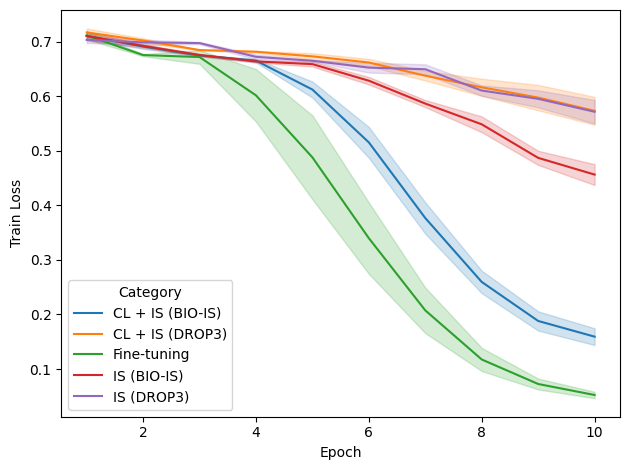

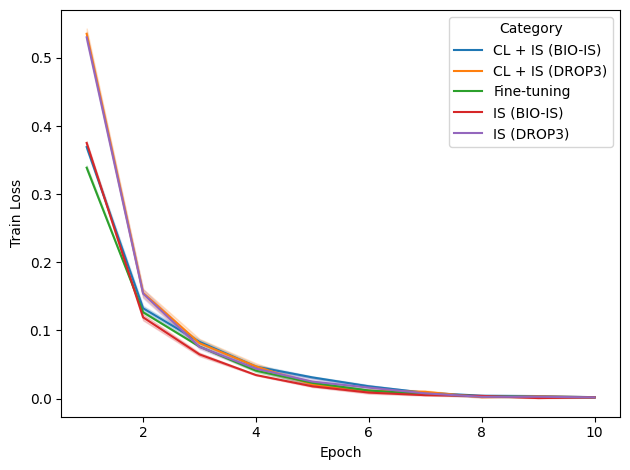

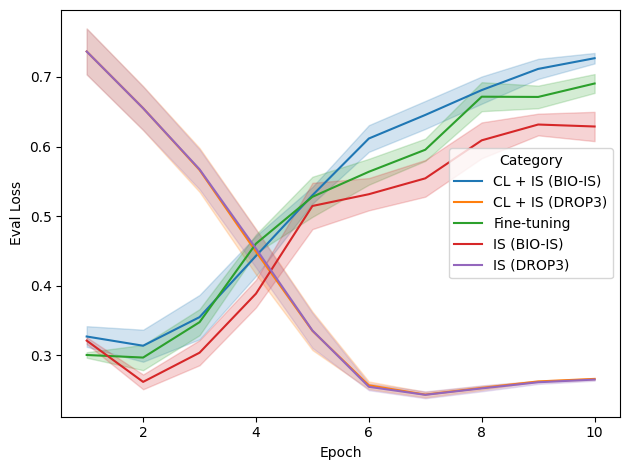

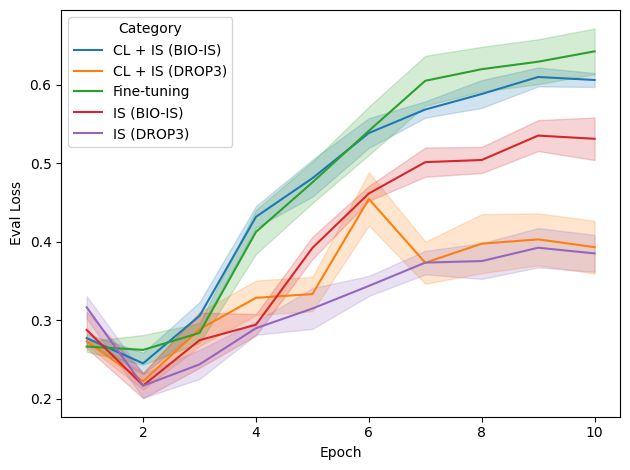

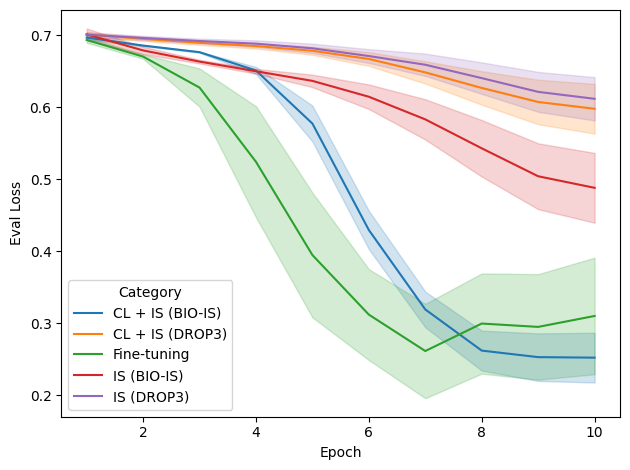

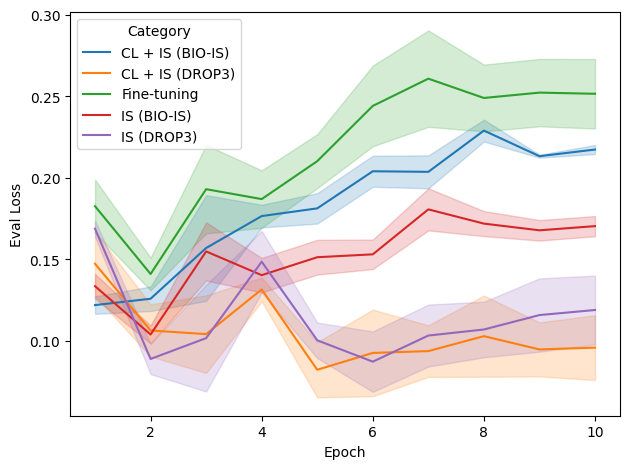

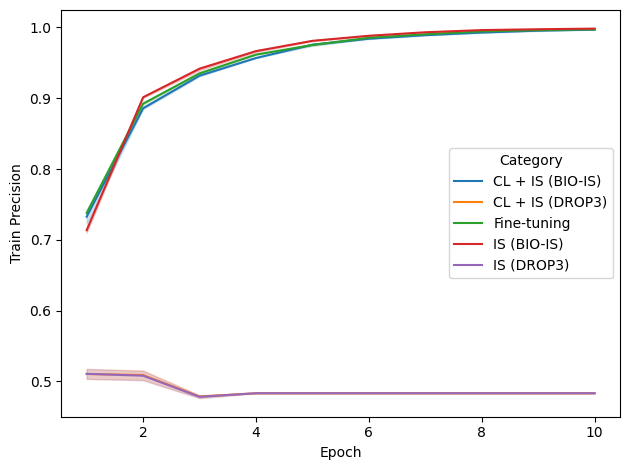

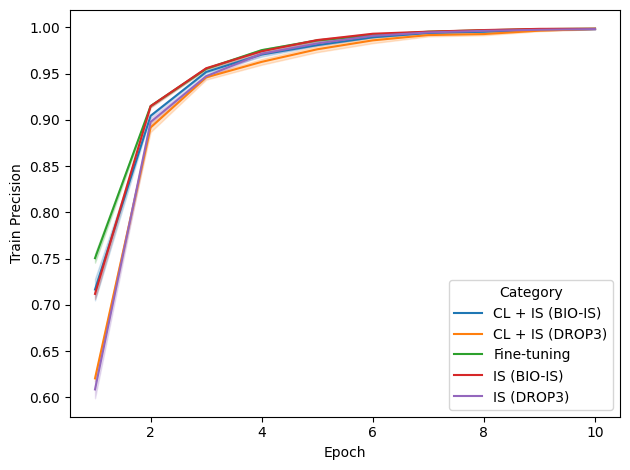

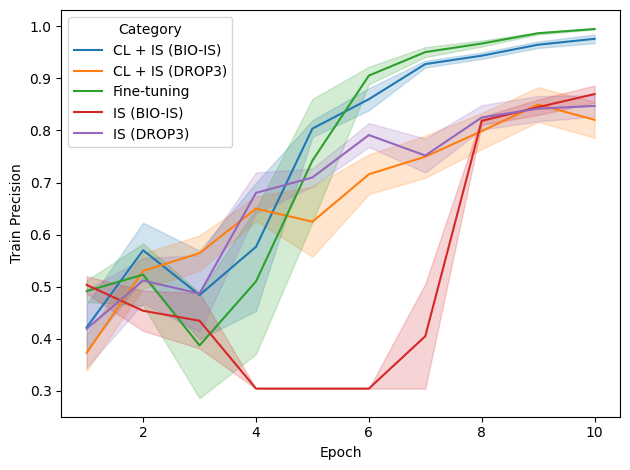

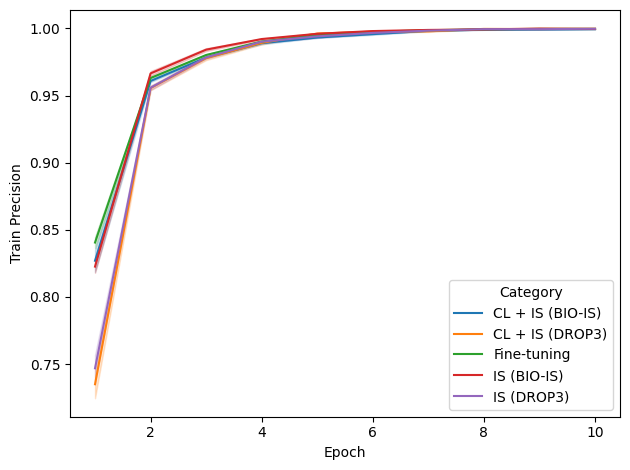

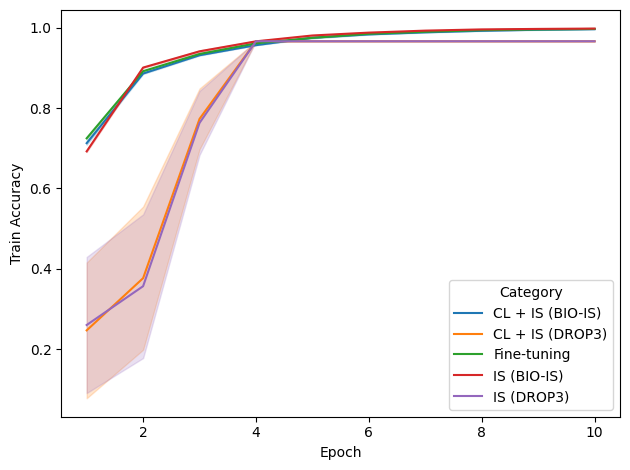

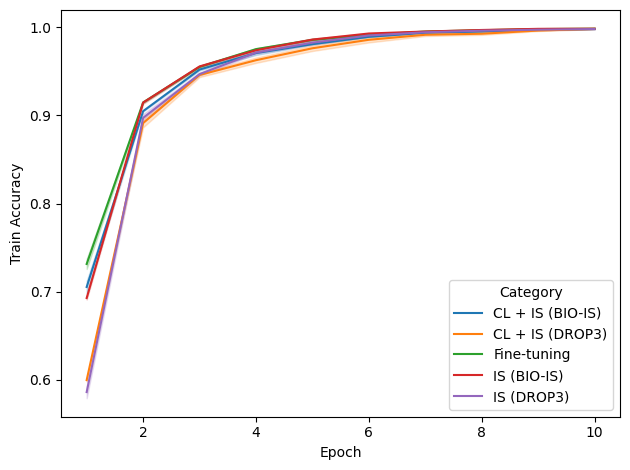

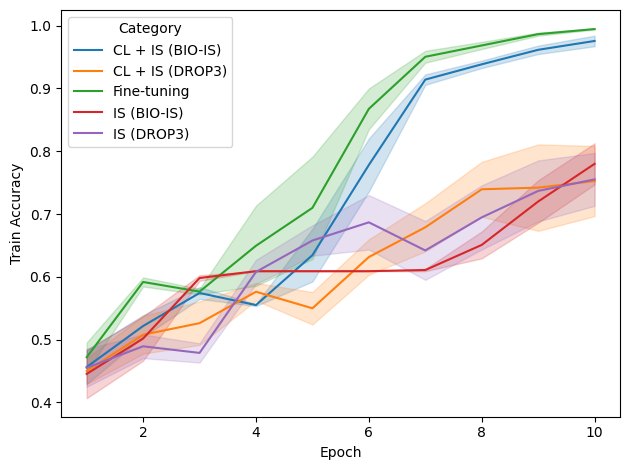

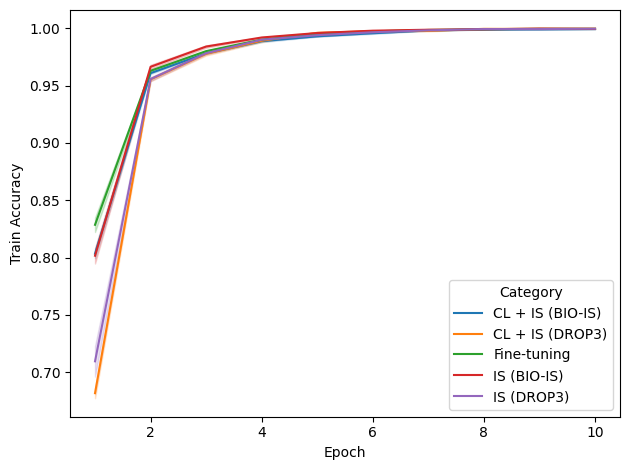

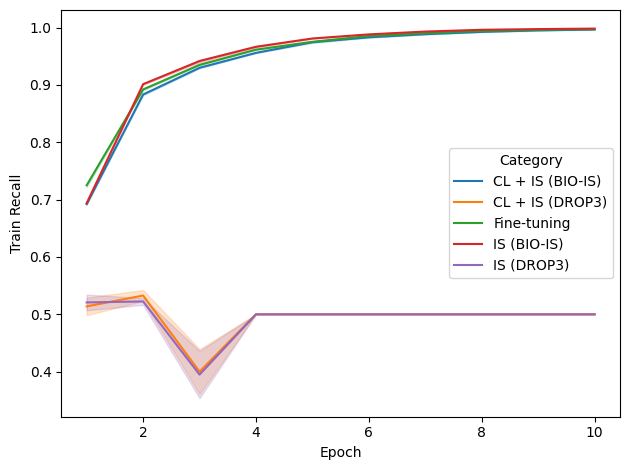

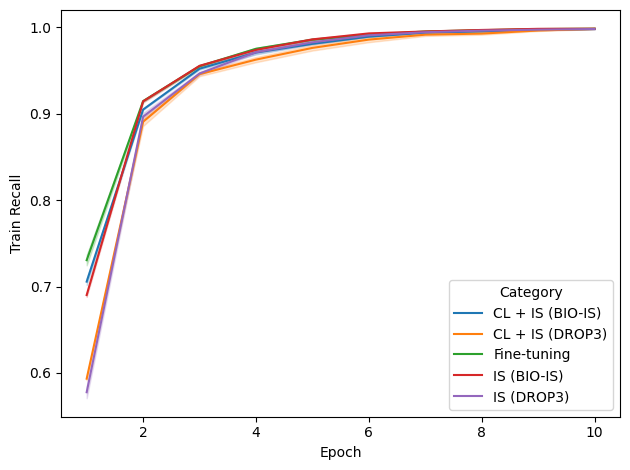

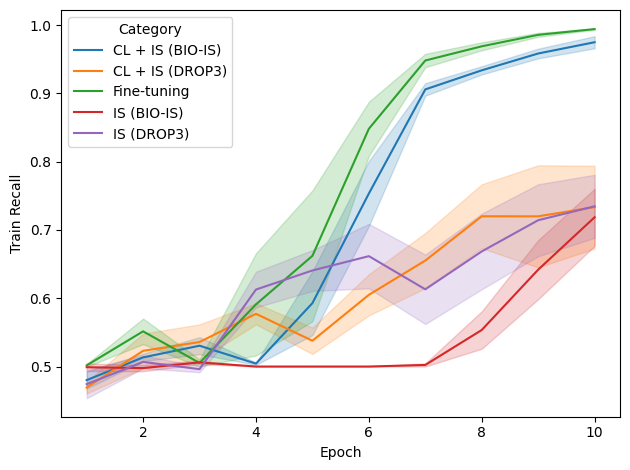

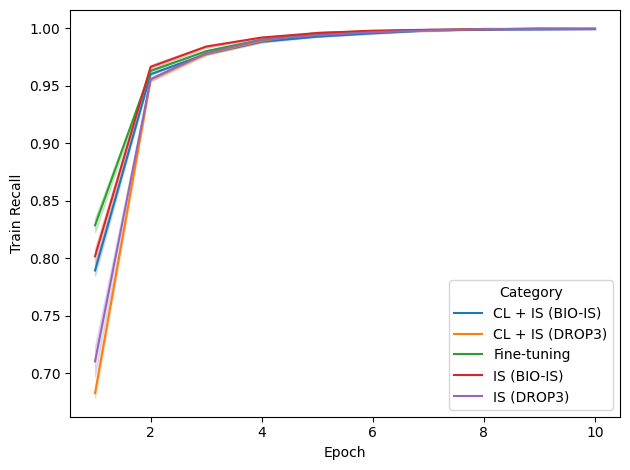

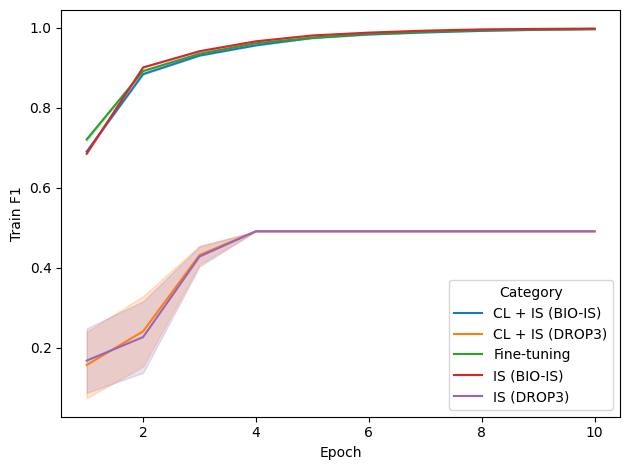

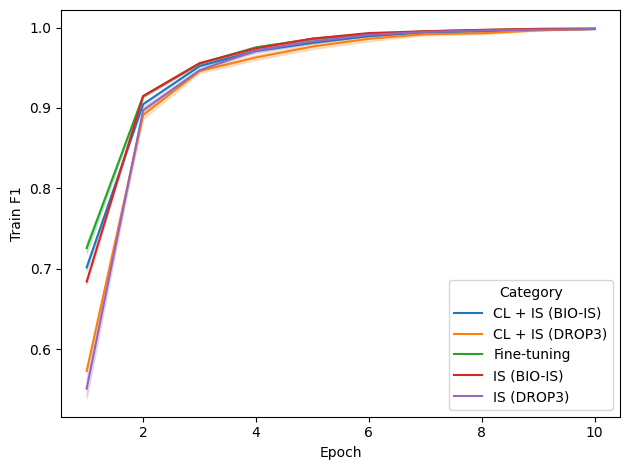

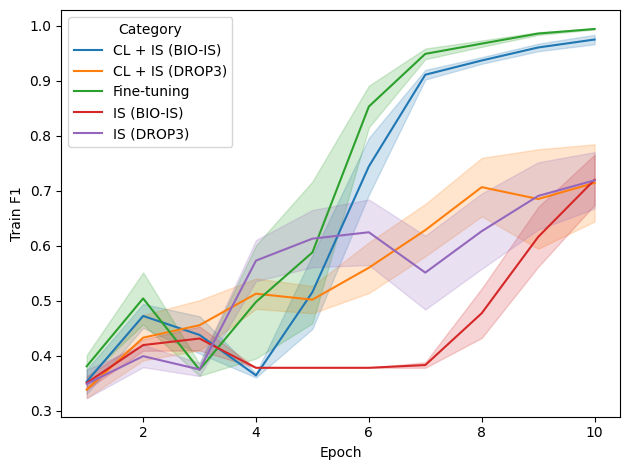

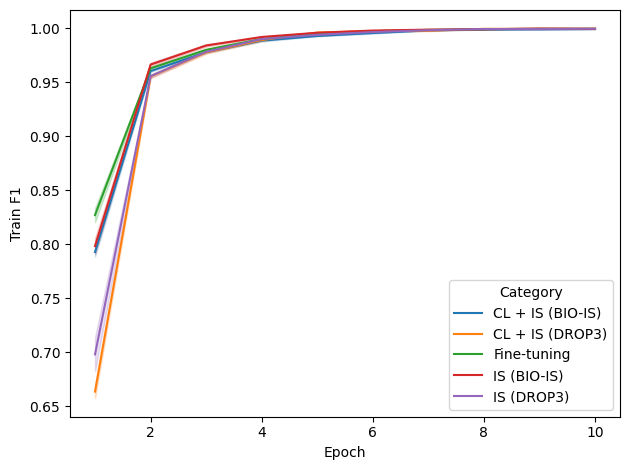

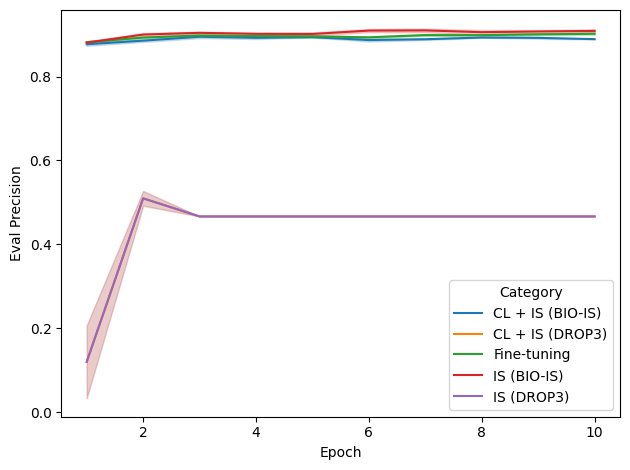

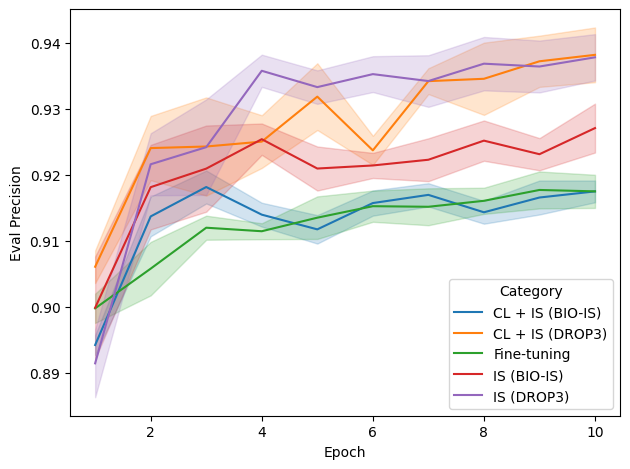

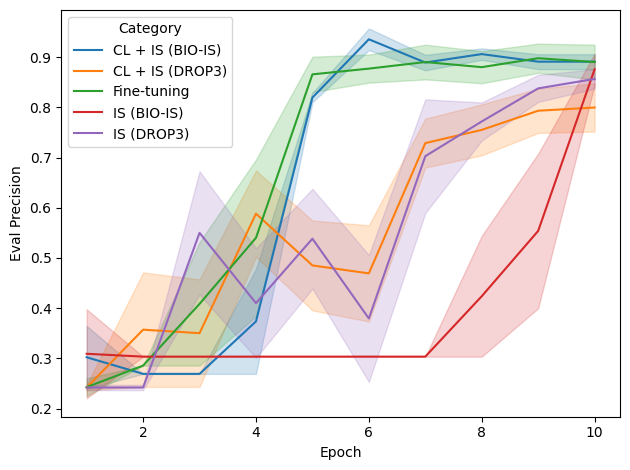

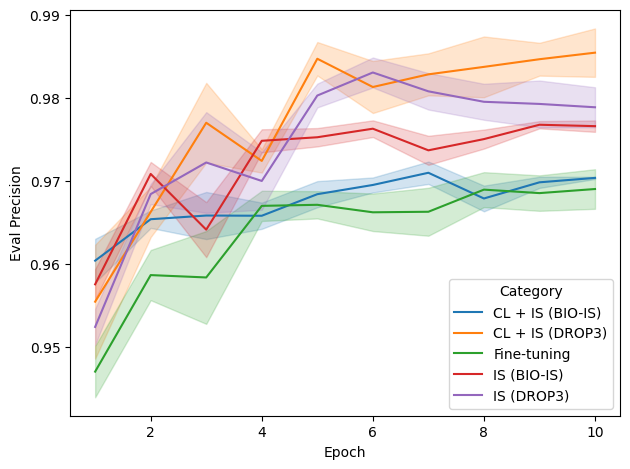

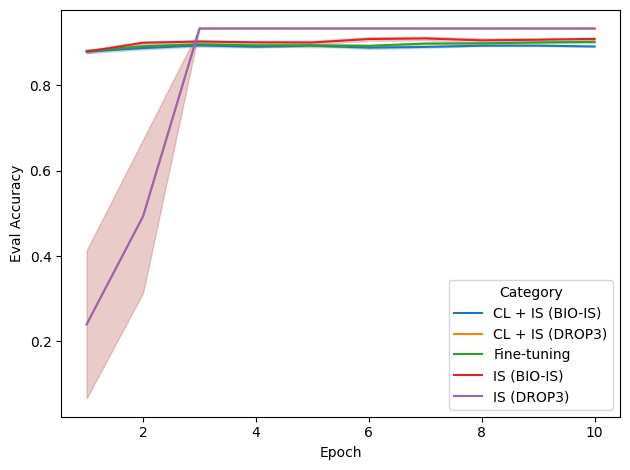

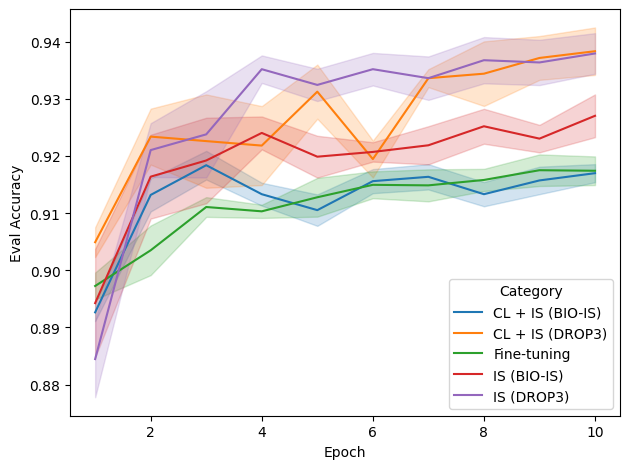

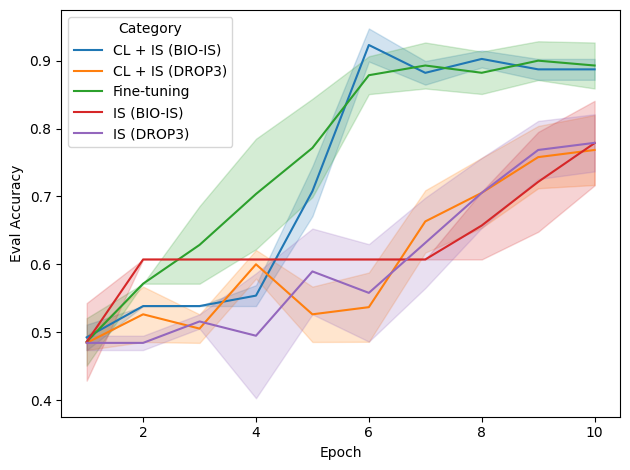

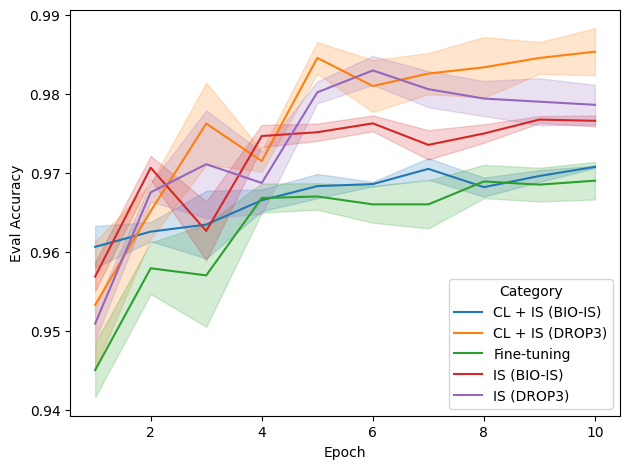

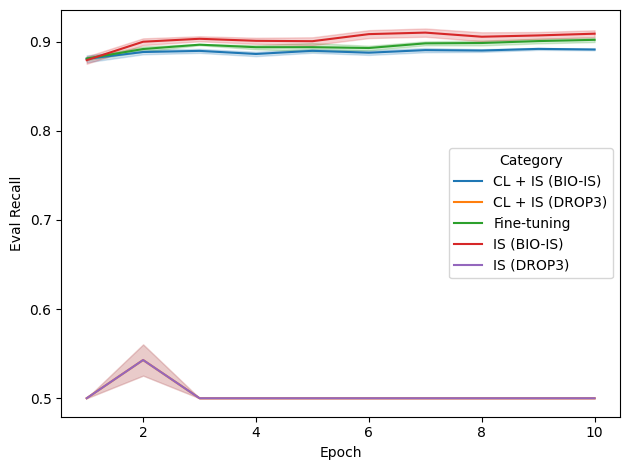

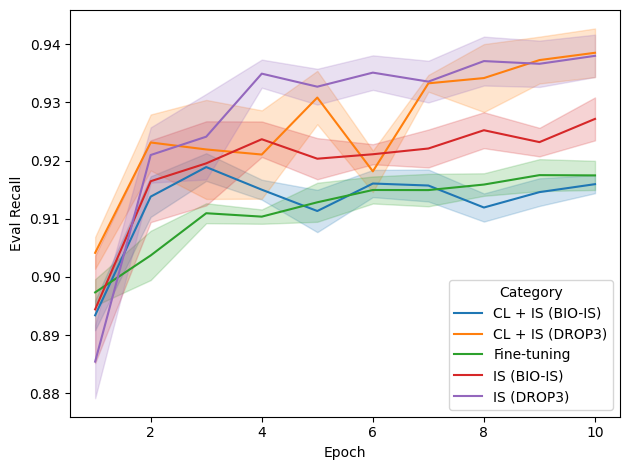

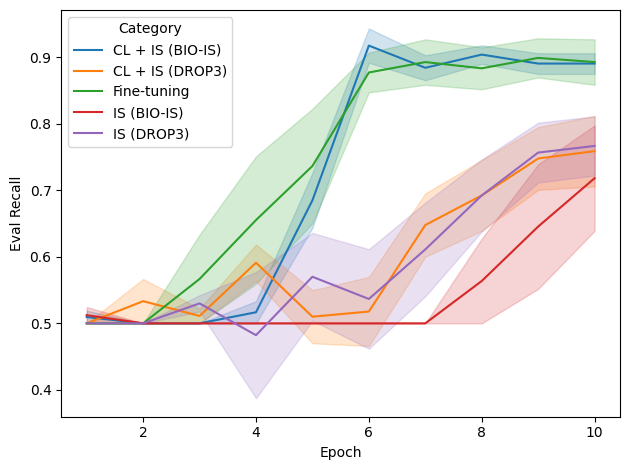

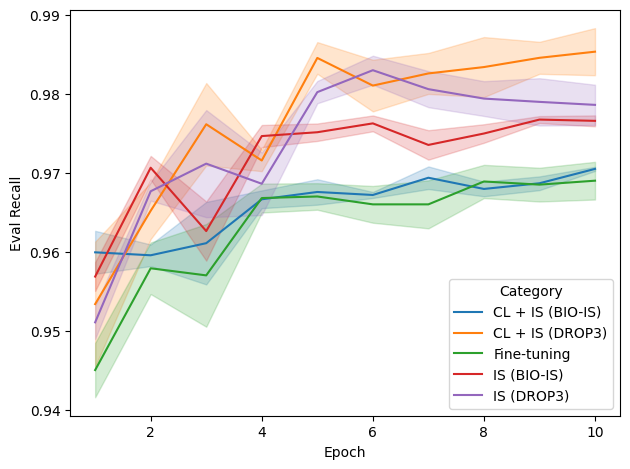

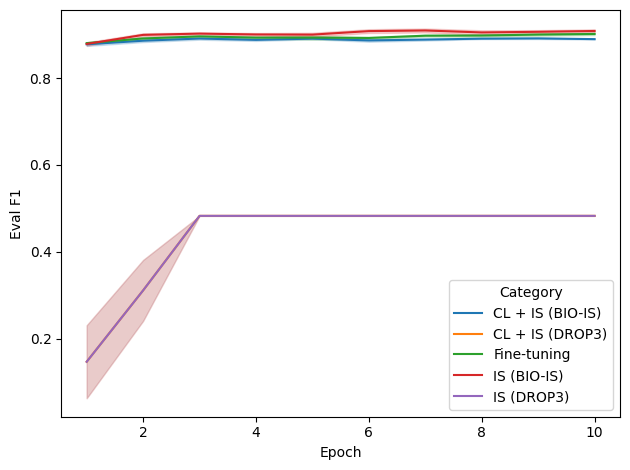

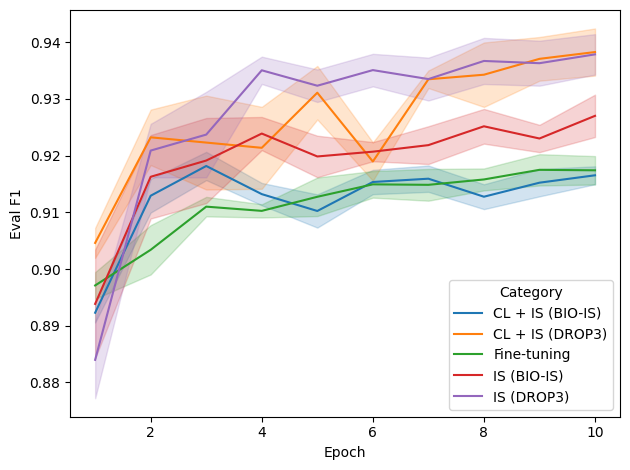

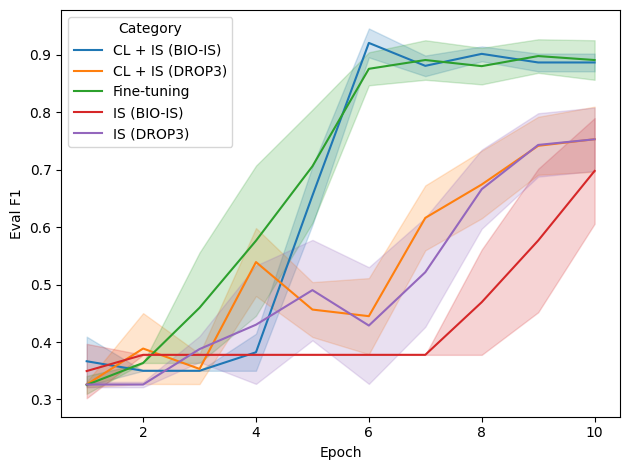

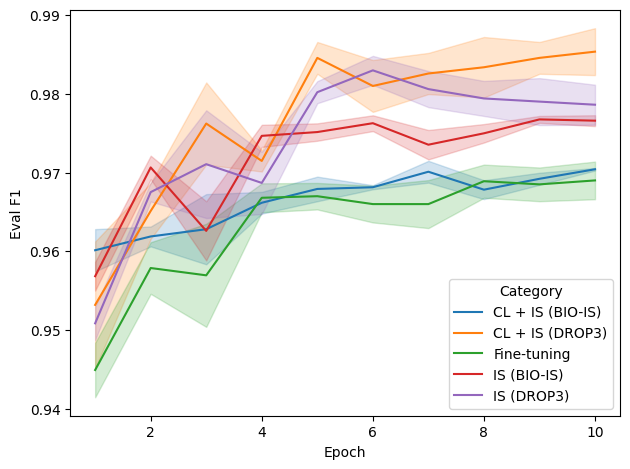

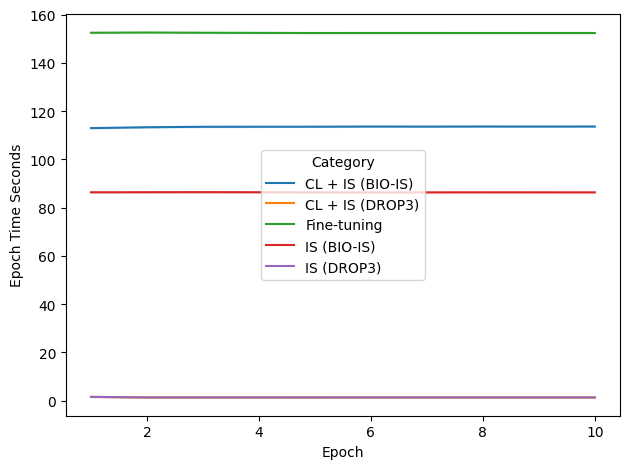

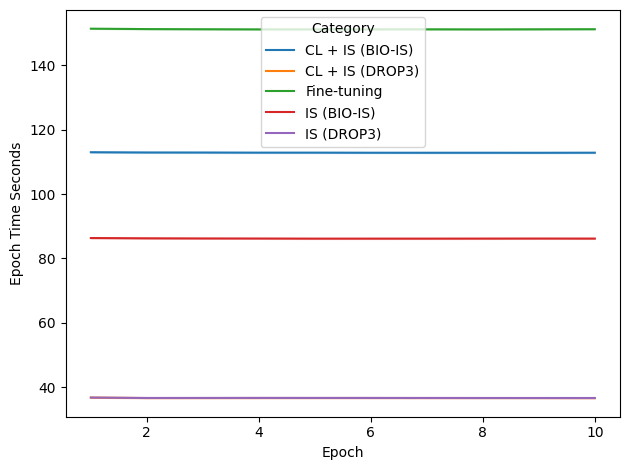

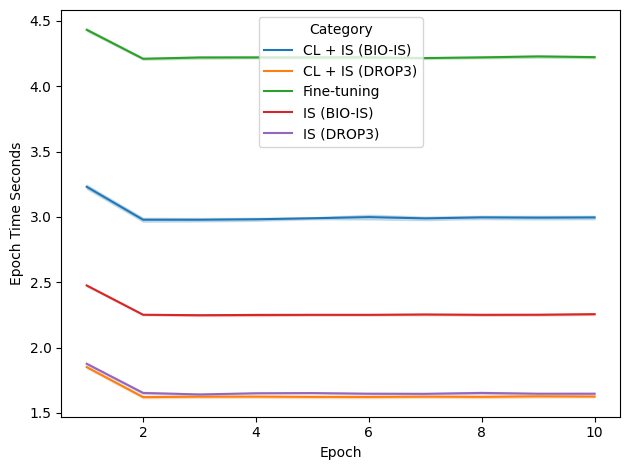

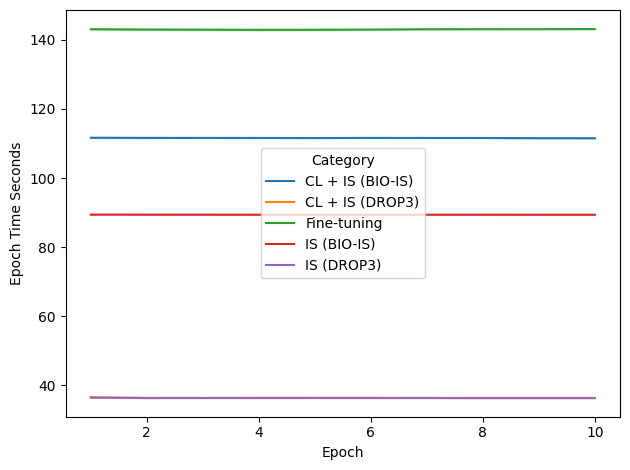

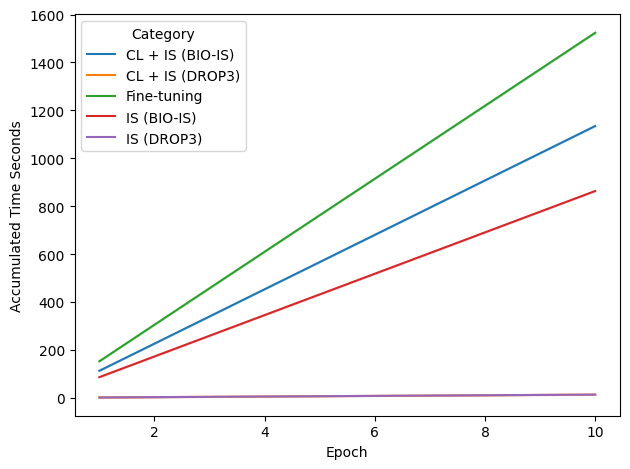

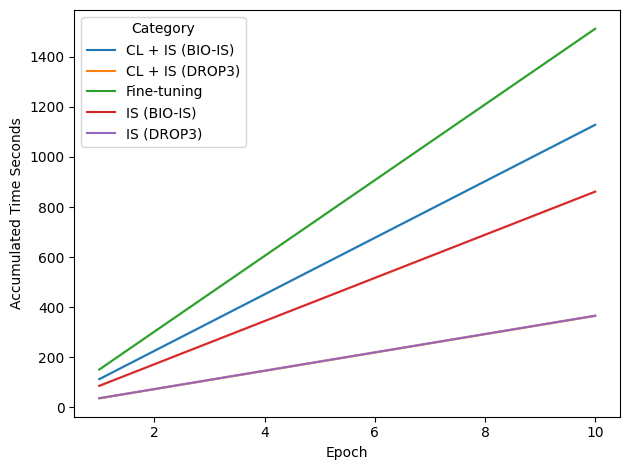

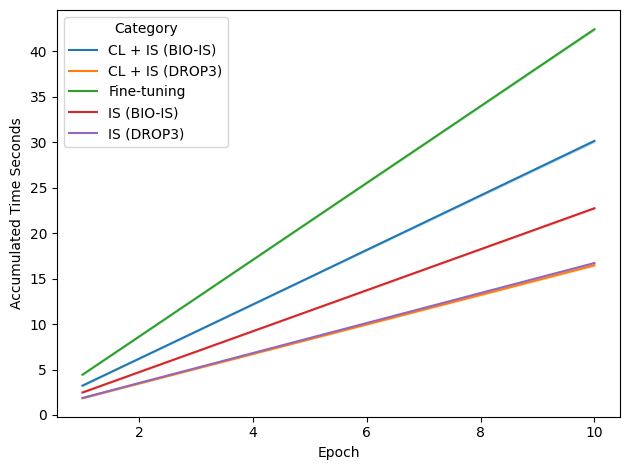

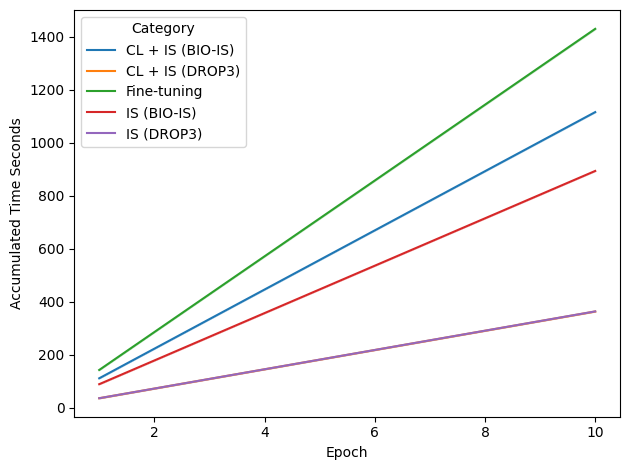

In [91]:
batch_df = pd.DataFrame()
perf_df = pd.DataFrame()

for file in glob("*/*/*.csv"):
    if m := re.match("iter(\\d)/(.*)/(.*)_out.csv", file):
        try:
            iter_num = m[1]
            method = [met for met in methods if met in m[3]]
            method = method[0] if len(method) else ""
            category = f"{m[2]}_{method}"
            dataset = [d for d in datasets if d in m[3]][0]
            is_batch = "batch" in m[3]
            df = pd.read_csv(file)
            df["iter"] = iter_num
            df["category"] = category
            df["dataset"] = dataset
            if is_batch:
                batch_df = pd.concat((batch_df, df))
            else:
                perf_df = pd.concat((perf_df, df))
        except Exception as e:
            print(e)
            continue

perf_columns = [
 'train_loss',
 'eval_loss',
 'train_precision',
 'train_accuracy',
 'train_recall',
 'train_f1',
 'eval_precision',
 'eval_accuracy',
 'eval_recall',
 'eval_f1',
 'epoch_time_seconds',
 'accumulated_time_seconds',
]

df = perf_df.groupby(["category", "dataset", "epoch", "iter"])[perf_columns].agg("mean").reset_index()
# df.columns = ['_'.join(col) if len(col) > 1 else col for col in df.columns]
# df.columns = df.columns.get_level_values(0)
# print(set(df["category"]))
df.rename(columns={"category": "Category"}, inplace=True)

df["Category"] = df["Category"].map(lambda x: {'FT_': "Fine-tuning", 'IS_biois': 'IS (BIO-IS)', 'CL+IS_biois': 'CL + IS (BIO-IS)', 'IS_drop3': 'IS (DROP3)', 'CL+IS_drop3': 'CL + IS (DROP3)'}.get(x))

for col in perf_columns:
    for dataset in datasets:
        df_ = df.loc[df["dataset"] == dataset]
        fig, ax = plt.subplots()
        sns.lineplot(data=df_, x="epoch", y=col, errorbar="se", hue="Category", ax=ax)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(" ".join([s.capitalize() for s in ax.get_ylabel().split("_")]))
        fig.tight_layout()
        fig.savefig(f"figs/{dataset}_{col}.png", dpi=300)